# KNN Classification

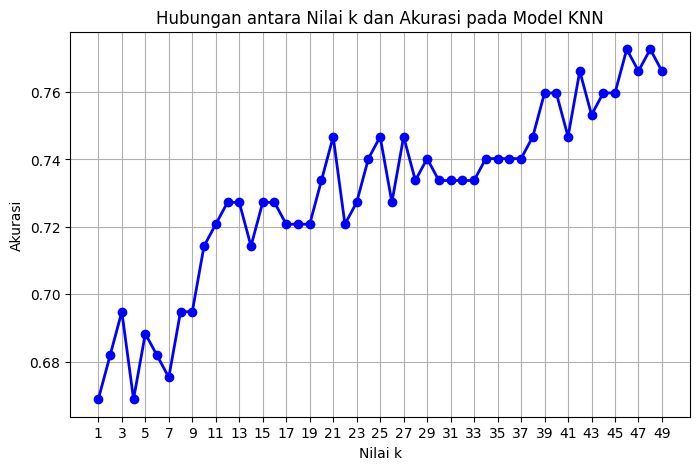

Nilai k terbaik berdasarkan akurasi: 46
Precision untuk k=46: 0.78
Recall untuk k=46: 0.51
F1 Score untuk k=46: 0.62
Akurasi Score untuk k=46: 0.77


: 

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

data = pd.read_csv('Data/diabetes.csv') 

# Memisahkan fitur dan target
X = data[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
          'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']].values
y = data['Outcome'].values

# Normalize data using Min-Max Scaling
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(X)

# Split dataset into training and testing
train_data, test_data, train_labels, test_labels = train_test_split(
    normalized_data, y, test_size=0.2, random_state=42)

# Menentukan rentang nilai k
k_values = range(1, 50)  
accuracies = []

# Mencoba berbagai nilai k
for k in k_values:
    # Membuat dan melatih model KNN
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(train_data, train_labels)

    # Melakukan prediksi
    predictions = knn.predict(test_data)

    # Hitung akurasi untuk nilai k tersebut
    accuracy = accuracy_score(test_labels, predictions)
    accuracies.append(accuracy)

# Plot hubungan antara k dan akurasi
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', color='b', linestyle='-', linewidth=2)
plt.xlabel('Nilai k')
plt.ylabel('Akurasi')
plt.title('Hubungan antara Nilai k dan Akurasi pada Model KNN')
plt.xticks(range(1, 50, 2))  # Menampilkan label sumbu X sebagai kelipatan 2
plt.grid(True)
plt.show()

# Pilih nilai k terbaik berdasarkan akurasi tertinggi
best_k = k_values[accuracies.index(max(accuracies))]
print(f"Nilai k terbaik berdasarkan akurasi: {best_k}")

# Membuat model KNN dengan k terbaik
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(train_data, train_labels)

# Melakukan prediksi untuk k terbaik
best_predictions = knn_best.predict(test_data)

# Menghitung metrik lainnya
precision = precision_score(test_labels, best_predictions)
recall = recall_score(test_labels, best_predictions)
f1 = f1_score(test_labels, best_predictions)
ac = accuracy_score(test_labels, best_predictions)

# Menampilkan hasil
print(f"Precision untuk k={best_k}: {precision:.2f}")
print(f"Recall untuk k={best_k}: {recall:.2f}")
print(f"F1 Score untuk k={best_k}: {f1:.2f}")
print(f"Akurasi Score untuk k={best_k}: {ac:.2f}")
